A jupyter notebook to interpolate data to z=300m for visulations.

In [27]:
import numpy as np
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import matplotlib
import matplotlib.colors as colors

In [28]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

def cubic_z_interp(h, field_vals_all, lon, lat, z_val):
    # Now make cubic interpolation coefficients for each grid staggering

    # Use the bottom four levels (in Python notation!)
    levels = [-1, -2, -3, -4]
    
    coeffs = np.zeros((4, len(lat), len(lon)))

    # Compute weights using interpolating polynomials
    coeffs[0] = (
        (z_val - h[levels[1]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[0]] - h[levels[1]]) * (h[levels[0]] - h[levels[2]])
        * (h[levels[0]] - h[levels[3]])
    )
    coeffs[1] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[1]] - h[levels[0]]) * (h[levels[1]] - h[levels[2]])
        * (h[levels[1]] - h[levels[3]])
    )
    coeffs[2] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[2]] - h[levels[0]]) * (h[levels[2]] - h[levels[1]])
        * (h[levels[2]] - h[levels[3]])
    )
    coeffs[3] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[2]])
    ) / (
        (h[levels[3]] - h[levels[0]]) * (h[levels[3]] - h[levels[1]])
        * (h[levels[3]] - h[levels[2]])
    )

    field_vals = np.zeros((len(lat), len(lon)))
    
    for i in np.arange(4):
        field_vals += coeffs[i]*field_vals_all[levels[i]]

    # Set values below surface to NaN
    field_vals = np.where(
        h[levels[0]] > z_val, np.nan, field_vals
    )
    
    return field_vals

In [29]:
# Choose the data to regrid
test = 'gap'
#test='vortex'

rot = False

#dycore = 'CAM-SE'
#dycore = 'CAM-FV3'
dycore = 'CAM-MPAS'

# Give an extra name to the file, for diffusion testing

# SE
#extra_name = '_diff_2x_weaker'

# Fv3
#extra_name = '_hord5'

# MPAS
#extra_name = '_divfact_1'

# No diffusion
extra_name = ''


In [30]:
if rot:
    rot_state='with_rot'
else:
    rot_state='omega0'

extra_savename = ''

if dycore == 'CAM-SE':
    case = f'cam_6_4_100_se_ne60_ztop20km_L57_new_RF'
    if test == 'gap':
        nc_file = f'{case}.cam.h0i.0001-01-01-00000_{test}_{rot_state}_tau_100s{extra_name}.nc'

    else:
        nc_file = f'{case}.cam.h0i.0001-01-01-00000_{test}_{rot_state}_tau100s{extra_name}.nc'
elif dycore == 'CAM-FV3':
    case = f'cam_6_4_070_horiz_mount_flow_fv3_C192_ztop20km_L57_new_RF'
    nc_file = f'{case}.cam.h0i.0001-01-01-00000_{test}_{rot_state}_tau100s{extra_name}.regrid.0.5x0.5.nc'
elif dycore == 'CAM-MPAS':
    #case = f'cam_6_4_080_paper_six_mpasa60_L20km_L57_new_RF_w0'

    # For nonzero w0:
    case = f'cam_6_4_080_paper_six_mpasa60_L20km_L57_new_RF'
    extra_savename = '_nonzero_w0'
    
    nc_file = f'{case}.cam.h0i.0001-01-01-00000_{test}_{rot_state}_tau100s{extra_name}.regrid.0.5x0.5.nc'

run_base = "/glade/derecho/scratch/timand/"
run_path = run_base + case + '/run/' + nc_file
nc = Dataset(run_path)

In [31]:
# Save the regridded data. Do so as net cdf
savename = f'{dycore}_{test}_{rot_state}{extra_name}{extra_savename}'
output_file = Dataset(f'/glade/u/home/timand/dcmip2025_gap_and_vortex/interpolate_data/interp_data/{savename}.nc', 'w')

time = nc['time'][:]
lat = nc['lat'][:] 
lon = nc['lon'][:]

output_file.createDimension('lon', len(lon))
output_file.createDimension('lat', len(lat))
lon_var = output_file.createVariable('lon', 'f4', ('lon',))
lat_var = output_file.createVariable('lat', 'f4', ('lat',))

output_file.variables['lon'][:] = lon
output_file.variables['lat'][:] = lat

In [32]:
# Perform regridding
z_val = 300

if test == 'gap':
    t_idx = 40
    t_idxs = np.arange(40)
elif test == 'vortex':
    t_idx = 80
    t_idxs = np.arange(80)

U_field_vals = cubic_z_interp(nc['Z3'][t_idx, :, :, :], nc['U'][t_idx, :, :, :], lon, lat, z_val)
output_file.createVariable('U', 'f4', ('lat', 'lon'))
output_file.variables['U'][:, :] = U_field_vals

V_field_vals = cubic_z_interp(nc['Z3'][t_idx, :, :, :], nc['V'][t_idx, :, :, :], lon, lat, z_val)
output_file.createVariable('V', 'f4', ('lat', 'lon'))
output_file.variables['V'][:, :] = V_field_vals

T_field_vals = cubic_z_interp(nc['Z3'][t_idx, :, :, :], nc['T'][t_idx, :, :, :], lon, lat, z_val)
output_file.createVariable('T', 'f4', ('lat', 'lon'))
output_file.variables['T'][:, :] = T_field_vals

output_file.close()

In [33]:
# lat lon values to plot at
lat_crop_up = 50.
lat_cent_down = -50.
lat_ticks = np.linspace(-40.,40.,5)

lon_crop_left = 140.
lon_crop_right = 280.
#lon_ticks = np.linspace(140, 280, 8)
lon_ticks = np.array([140,180,220,260])

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)


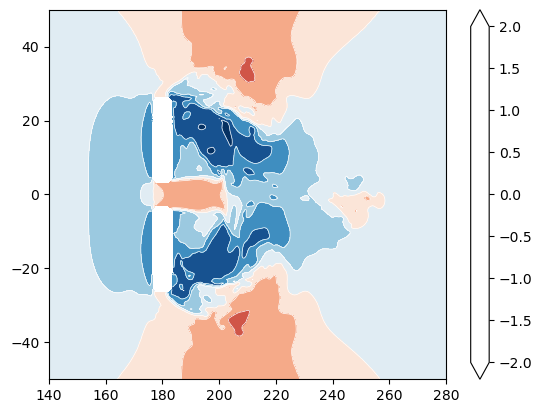

In [34]:
# Check the saved data looks fine

# Read in the saved data:
read_data = Dataset(f'/glade/u/home/timand/dcmip2025_gap_and_vortex/interpolate_data/interp_data/{savename}.nc', 'r')
#print(read_data.variables)

u0=10
deg2rad=np.pi/180

if test == 'gap':
    # Plot the U and T fields
    plt.figure()
    U_conts = np.linspace(-2.0, 2.0, 9)    
    U_cmap = matplotlib.cm.RdBu_r
    U_full = read_data['U'][lat_inds, lon_inds]
    U_pert = (U_full - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
    norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)
    plt.contourf(LON, LAT, U_pert, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
    plt.contour(LON, LAT, U_pert, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
    plt.colorbar()
    plt.show()
elif test == 'vortex':
    # Plot the U and T fields
    plt.figure()
    U_conts = np.linspace(-1, 0.5, 13)
    U_cmap = 'seismic'
    U_full = read_data['U'][lat_inds, lon_inds]
    U_pert = (U_full - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
    norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)
    plt.contourf(LON, LAT, U_pert, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
    plt.contour(LON, LAT, U_pert, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
    plt.colorbar()
    plt.show()

In [35]:
# Check groups of net cdf